In [5]:
from pathlib import Path
import os

PROJECT_ROOT = Path("/Users/zachmontbach/crypto-vol-project")
os.chdir(PROJECT_ROOT)

print(Path.cwd())

/Users/zachmontbach/crypto-vol-project


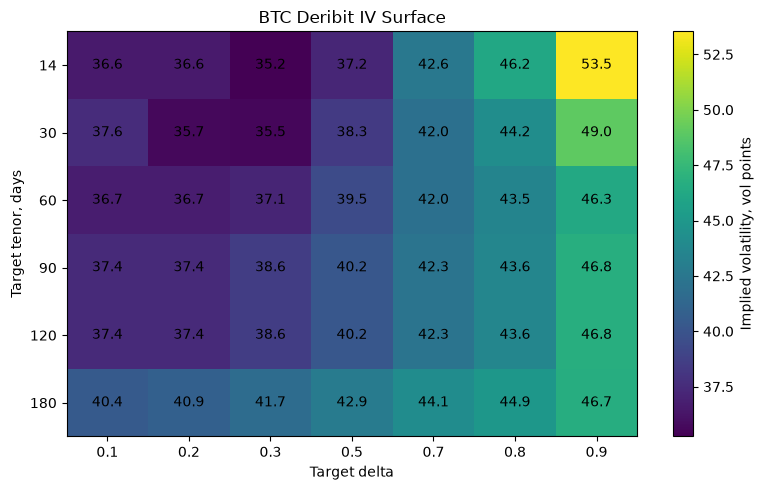

Saved figure to results/figures/BTC_latest_iv_surface.png


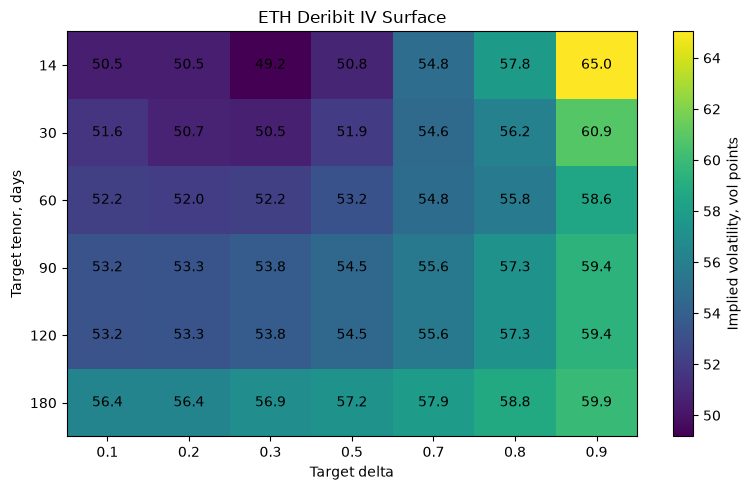

Saved figure to results/figures/ETH_latest_iv_surface.png


In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

TENORS = [14, 30, 60, 90, 120, 180]
DELTAS = [0.10, 0.20, 0.30, 0.50, 0.70, 0.80, 0.90]


def plot_surface(currency: str) -> None:
    data = np.load(f"data/processed/{currency}_latest_surface.npz")
    surface = data["surface"] * 100

    df = pd.DataFrame(surface, index=TENORS, columns=DELTAS)

    plt.figure(figsize=(8, 5))
    plt.imshow(df.values, aspect="auto")
    plt.colorbar(label="Implied volatility, vol points")
    plt.xticks(range(len(DELTAS)), DELTAS)
    plt.yticks(range(len(TENORS)), TENORS)
    plt.xlabel("Target delta")
    plt.ylabel("Target tenor, days")
    plt.title(f"{currency} Deribit IV Surface")

    for i in range(len(TENORS)):
        for j in range(len(DELTAS)):
            plt.text(j, i, f"{df.iloc[i, j]:.1f}", ha="center", va="center")

    out = Path("results/figures") / f"{currency}_latest_iv_surface.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.tight_layout()
    plt.savefig(out, dpi=200)
    plt.show()

    print(f"Saved figure to {out}")


if __name__ == "__main__":
    plot_surface("BTC")
    plot_surface("ETH")